In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

#Загрузка данных
df = sns.load_dataset('penguins')

In [ ]:
#Удаляем строки в которых пропущена целевая переменная
df = df.dropna(subset=['body_mass_g'])

#Разделение на признаки и целевую переменную
X = df.drop('body_mass_g', axis=1)
y = df['body_mass_g']

#Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Определение числовых и категориальных признаков
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
categorical_features = ['species', 'island', 'sex']

#Создание преобразований данных
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Объединение преобразований
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

#Создание моделей
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

#Пустой список для результатов
results = []

In [ ]:
for name, model in models.items():
    #Создание pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    #Обучение модели
    pipeline.fit(X_train, y_train)

    #Предсказания
    y_pred = pipeline.predict(X_test)

    #Вычисление метрик
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    #Сохранение результатов
    results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'MAPE': mape,
        'Predictions': y_pred
    })


Сравнение моделей:
            Model        MSE    MAE  MAPE
Linear Regression  82,185.98 232.24  6.04
    Random Forest 108,424.28 263.21  6.85
Gradient Boosting  89,663.97 238.81  6.22


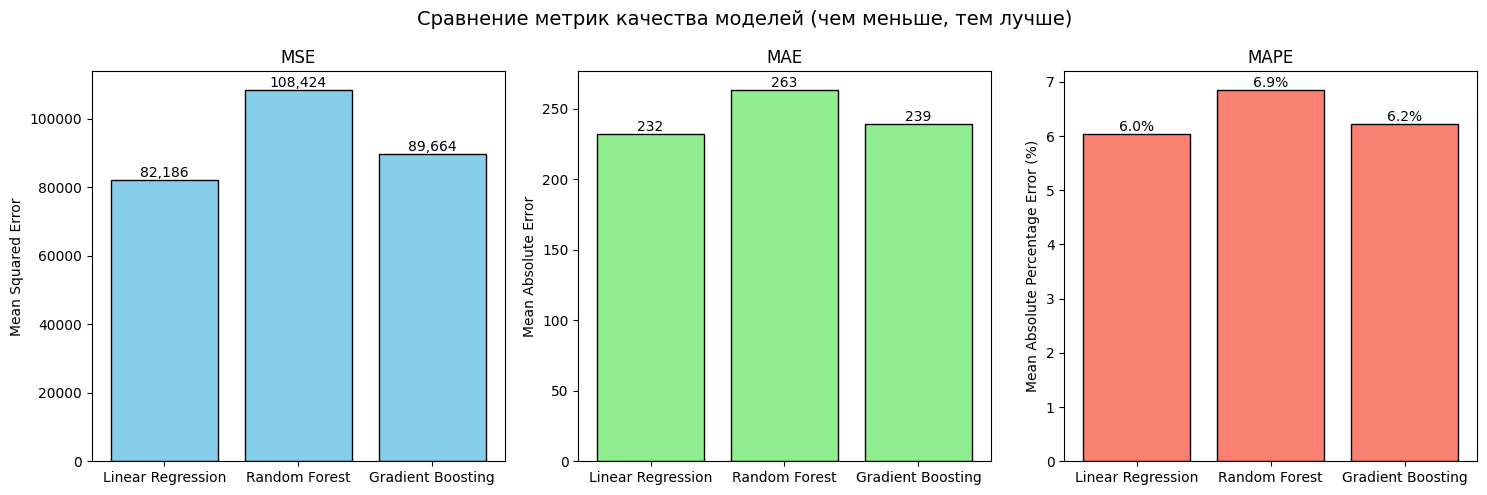

In [ ]:
#Создание DataFrame с результатами
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Predictions'} for r in results])

print("\nСравнение моделей:")
print(results_df.to_string(index=False, float_format='{:,.2f}'.format))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Сравнение метрик качества моделей (чем меньше, тем лучше)', fontsize=14)

#График 1: MSE
axes[0].bar(results_df['Model'], results_df['MSE'], color='skyblue', edgecolor='black')
axes[0].set_title('MSE')
axes[0].set_ylabel('Mean Squared Error')
axes[0].tick_params(axis='x')
for i, v in enumerate(results_df['MSE']):
    axes[0].text(i, v, f'{v:,.0f}', ha='center', va='bottom')

#График 2: MAE
axes[1].bar(results_df['Model'], results_df['MAE'], color='lightgreen', edgecolor='black')
axes[1].set_title('MAE')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].tick_params(axis='x')
for i, v in enumerate(results_df['MAE']):
    axes[1].text(i, v, f'{v:.0f}', ha='center', va='bottom')

#График 3: MAPE
axes[2].bar(results_df['Model'], results_df['MAPE'], color='salmon', edgecolor='black')
axes[2].set_title('MAPE')
axes[2].set_ylabel('Mean Absolute Percentage Error (%)')
axes[2].tick_params(axis='x')
for i, v in enumerate(results_df['MAPE']):
    axes[2].text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

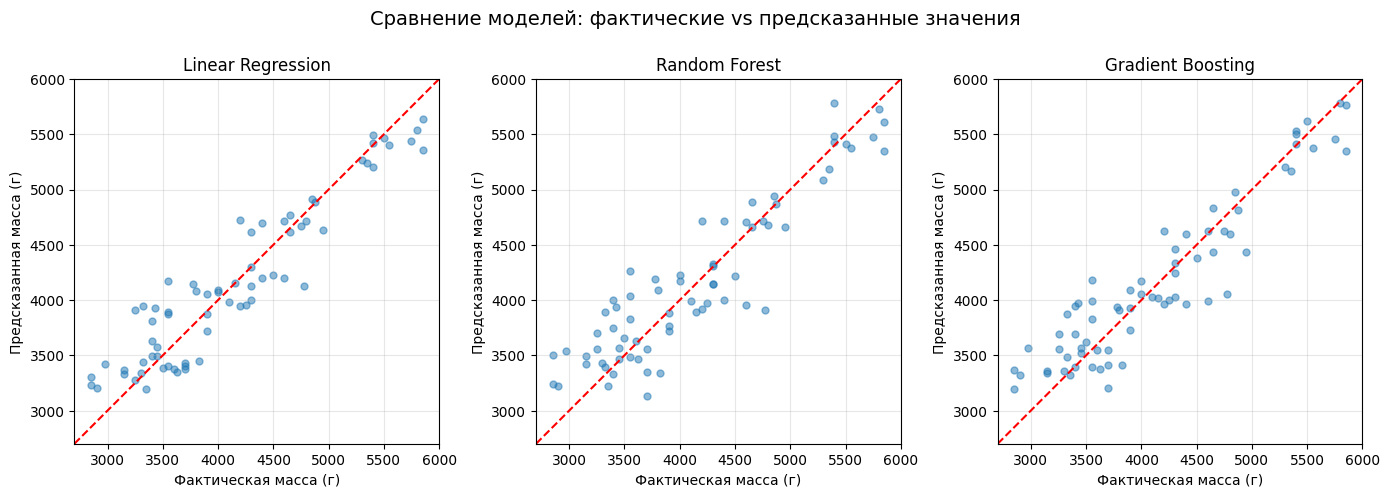

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Сравнение моделей: фактические vs предсказанные значения', fontsize=14)

#Общие границы для всех графиков
all_predictions = [r['Predictions'] for r in results]
all_values = np.concatenate([y_test.values] + all_predictions)
min_val = all_values.min()
max_val = all_values.max()
padding = (max_val - min_val) * 0.05
min_val_padded = min_val - padding
max_val_padded = max_val + padding

for i, result in enumerate(results):
    ax = axes[i]
    y_pred = result['Predictions']

    ax.scatter(y_test, y_pred,  alpha=0.5,  s=25)
    ax.plot([min_val_padded, max_val_padded], [min_val_padded, max_val_padded], 'r--')

    ax.set_xlabel('Фактическая масса (г)')
    ax.set_ylabel('Предсказанная масса (г)')
    ax.set_title(result["Model"])

    ax.grid(True, alpha=0.3)
    ax.set_xlim(min_val_padded, max_val_padded)
    ax.set_ylim(min_val_padded, max_val_padded)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

## Вывод
Для данного набора данных модель Linear Regression показала лучший результат по всем трем метрикам (MSE    MAE  MAPE).
Gradient Boosting занял второе место, а Random Forest показал худший результат.

Но в целом все модели предсказали вес с достаточно высокой точностью (6-7%)

#Предположения
Скорее всего Linear Regression лучше других справилась с задачей так как данные содержат линейные зависимости между признаками и целевой переменной. Для таких случаев это наиболее простая и точная модель.

Возможно при более тонком подборе параметров для Random Forest и Gradient Boosting они дали бы более точные результаты.